# NCF 


In [1]:
%pip install recommenders -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
USE_GPU = True

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"TensorFlow: найдено GPU: {len(gpus)}")
    for g in gpus:
        print(f"  - {g}")
else:
    print("TensorFlow: GPU не найден, используется CPU")
    if USE_GPU:
        print("  (USE_GPU=True, но GPU недоступен)")


TensorFlow: найдено GPU: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [11]:
%pip install tf_slim

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from recommenders.models.ncf.ncf_singlenode import NCF
from recommenders.models.ncf.dataset import Dataset as NCFDataset
from recommenders.evaluation.python_evaluation import (
    precision_at_k, recall_at_k, ndcg_at_k, map_at_k
)
from recommenders.utils.constants import (
    DEFAULT_USER_COL, DEFAULT_ITEM_COL,
    DEFAULT_RATING_COL, DEFAULT_TIMESTAMP_COL
)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

print(f"User col:   '{DEFAULT_USER_COL}'")
print(f"Item col:   '{DEFAULT_ITEM_COL}'")
print(f"Rating col: '{DEFAULT_RATING_COL}'")

User col:   'userID'
Item col:   'itemID'
Rating col: 'rating'


In [13]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Исходный датасет: {df.shape}")

df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

MIN_INTERACTIONS = 3
user_counts = df_filtered.groupby('Телефон_new').size()
item_counts = df_filtered.groupby('ID_SKU').size()
active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
before = len(df_filtered)
df_filtered = df_filtered[
    df_filtered['Телефон_new'].isin(active_users) &
    df_filtered['ID_SKU'].isin(active_items)
]
print(f"Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"Товаров:       {df_filtered['ID_SKU'].nunique():,}")
print(f"Взаимодействий:{len(df_filtered):,}")

Исходный датасет: (610913, 16)
Пользователей: 35,395
Товаров:       22,198
Взаимодействий:314,493


In [14]:
interactions = (
    df_filtered
    .groupby(['Телефон_new', 'ID_SKU'])
    .agg(timestamp=('Дата', 'max'))
    .reset_index()
)
interactions[DEFAULT_RATING_COL] = 1.0
interactions.rename(columns={
    'Телефон_new': DEFAULT_USER_COL,
    'ID_SKU':      DEFAULT_ITEM_COL,
    'timestamp':   DEFAULT_TIMESTAMP_COL
}, inplace=True)

interactions = interactions.sort_values(DEFAULT_TIMESTAMP_COL)
split_ts = interactions[DEFAULT_TIMESTAMP_COL].quantile(0.7)
print(f"Дата разделения: {split_ts}")

train_df = interactions[interactions[DEFAULT_TIMESTAMP_COL] <  split_ts].copy()
test_df  = interactions[interactions[DEFAULT_TIMESTAMP_COL] >= split_ts].copy()

train_users = set(train_df[DEFAULT_USER_COL].unique())
test_df = test_df[test_df[DEFAULT_USER_COL].isin(train_users)]

print(f"Train: {len(train_df):,} пар, {train_df[DEFAULT_USER_COL].nunique():,} users")
print(f"Test:  {len(test_df):,} пар,  {test_df[DEFAULT_USER_COL].nunique():,} users")

Дата разделения: 2017-04-12 17:37:00
Train: 201,147 пар, 28,017 users
Test:  42,415 пар,  7,128 users


In [15]:
import tempfile, os

user2id = {u: i for i, u in enumerate(interactions[DEFAULT_USER_COL].unique())}
item2id = {it: i for i, it in enumerate(interactions[DEFAULT_ITEM_COL].unique())}

def encode(df):
    d = df.copy()
    d[DEFAULT_USER_COL] = d[DEFAULT_USER_COL].map(user2id)
    d[DEFAULT_ITEM_COL] = d[DEFAULT_ITEM_COL].map(item2id)
    return d

train_enc = encode(train_df).sort_values(DEFAULT_USER_COL)
test_enc  = encode(test_df).sort_values(DEFAULT_USER_COL)

tmp_dir    = tempfile.mkdtemp()
train_file = os.path.join(tmp_dir, 'train.csv')
test_file  = os.path.join(tmp_dir, 'test.csv')

train_enc[[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL]].to_csv(train_file, index=False)
test_enc[[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL]].to_csv(test_file,  index=False)

data = NCFDataset(
    train_file=train_file,
    test_file=test_file,
    seed=42,
    n_neg=4,
    n_neg_test=99,
    col_user=DEFAULT_USER_COL,
    col_item=DEFAULT_ITEM_COL,
    col_rating=DEFAULT_RATING_COL,
)

print(f"Пользователей: {data.n_users:,}")
print(f"Товаров:       {data.n_items:,}")

INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp65w415ed/train.csv ...
INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp65w415ed/test.csv ...
INFO:recommenders.models.ncf.dataset:Creating full leave-one-out test file /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp65w415ed/test_full.csv ...
100%|██████████| 7128/7128 [00:22<00:00, 319.82it/s]
INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmp65w415ed/test_full.csv ...


Пользователей: 28,017
Товаров:       20,699


In [8]:
model = NCF(
    n_users=data.n_users,
    n_items=data.n_items,
    model_type='NeuMF',
    n_factors=64,
    layer_sizes=[256, 128, 64],
    n_epochs=20,
    batch_size=1024,
    learning_rate=1e-3,
    verbose=2,
    seed=42,
)

model.fit(data)

2026-04-11 17:53:37.236180: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-11 17:53:37.236197: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 2 [178.10s]: train_loss = 2.178052 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 4 [183.57s]: train_loss = 3.029384 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 6 [184.42s]: train_loss = 2.807284 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 8 [177.79s]: train_loss = 3.433359 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 10 [181.06s]: train_loss = 3.614405 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 12 [17

In [16]:
known_users = set(model.user2id.keys())
known_items = sorted(model.item2id.keys())

test_users_eval = [u for u in test_enc[DEFAULT_USER_COL].unique() if u in known_users]

all_predictions = []
for user in test_users_eval:
    scores = model.predict(
        [user] * len(known_items),
        known_items,
        is_list=True
    )
    for item, score in zip(known_items, scores):
        all_predictions.append({
            DEFAULT_USER_COL:   user,
            DEFAULT_ITEM_COL:   item,
            DEFAULT_RATING_COL: score
        })

predictions_df = pd.DataFrame(all_predictions)
print(f"Предсказаний: {len(predictions_df):,}")
print(predictions_df.head())

Предсказаний: 147,542,472
   userID  itemID  rating
0       7       0     0.0
1       7       1     0.0
2       7       2     0.0
3       7       3     0.0
4       7       4     0.0


In [17]:
test_enc_eval = test_enc[
    test_enc[DEFAULT_USER_COL].isin(known_users) &
    test_enc[DEFAULT_ITEM_COL].isin(known_items)
]

results = {}
for k in [5, 10, 20]:
    results[k] = {
        'precision': precision_at_k(test_enc_eval, predictions_df, k=k,
                                    col_user=DEFAULT_USER_COL,
                                    col_item=DEFAULT_ITEM_COL,
                                    col_rating=DEFAULT_RATING_COL,
                                    col_prediction=DEFAULT_RATING_COL),
        'recall':    recall_at_k(test_enc_eval, predictions_df, k=k,
                                 col_user=DEFAULT_USER_COL,
                                 col_item=DEFAULT_ITEM_COL,
                                 col_rating=DEFAULT_RATING_COL,
                                 col_prediction=DEFAULT_RATING_COL),
        'ndcg':      ndcg_at_k(test_enc_eval, predictions_df, k=k,
                               col_user=DEFAULT_USER_COL,
                               col_item=DEFAULT_ITEM_COL,
                               col_rating=DEFAULT_RATING_COL,
                               col_prediction=DEFAULT_RATING_COL),
        'map':       map_at_k(test_enc_eval, predictions_df, k=k,
                              col_user=DEFAULT_USER_COL,
                              col_item=DEFAULT_ITEM_COL,
                              col_rating=DEFAULT_RATING_COL,
                              col_prediction=DEFAULT_RATING_COL),
    }

for k in [5, 10, 20]:
    r = results[k]
    print(f"\nK={k}:")
    print(f"  Precision@{k}: {r['precision']:.4f}")
    print(f"  Recall@{k}:    {r['recall']:.4f}")
    print(f"  MAP@{k}:       {r['map']:.4f}")
    print(f"  NDCG@{k}:      {r['ndcg']:.4f}")


K=5:
  Precision@5: 0.0034
  Recall@5:    0.0018
  MAP@5:       0.0016
  NDCG@5:      0.0032

K=10:
  Precision@10: 0.0052
  Recall@10:    0.0057
  MAP@10:       0.0018
  NDCG@10:      0.0052

K=20:
  Precision@20: 0.0081
  Recall@20:    0.0230
  MAP@20:       0.0032
  NDCG@20:      0.0118


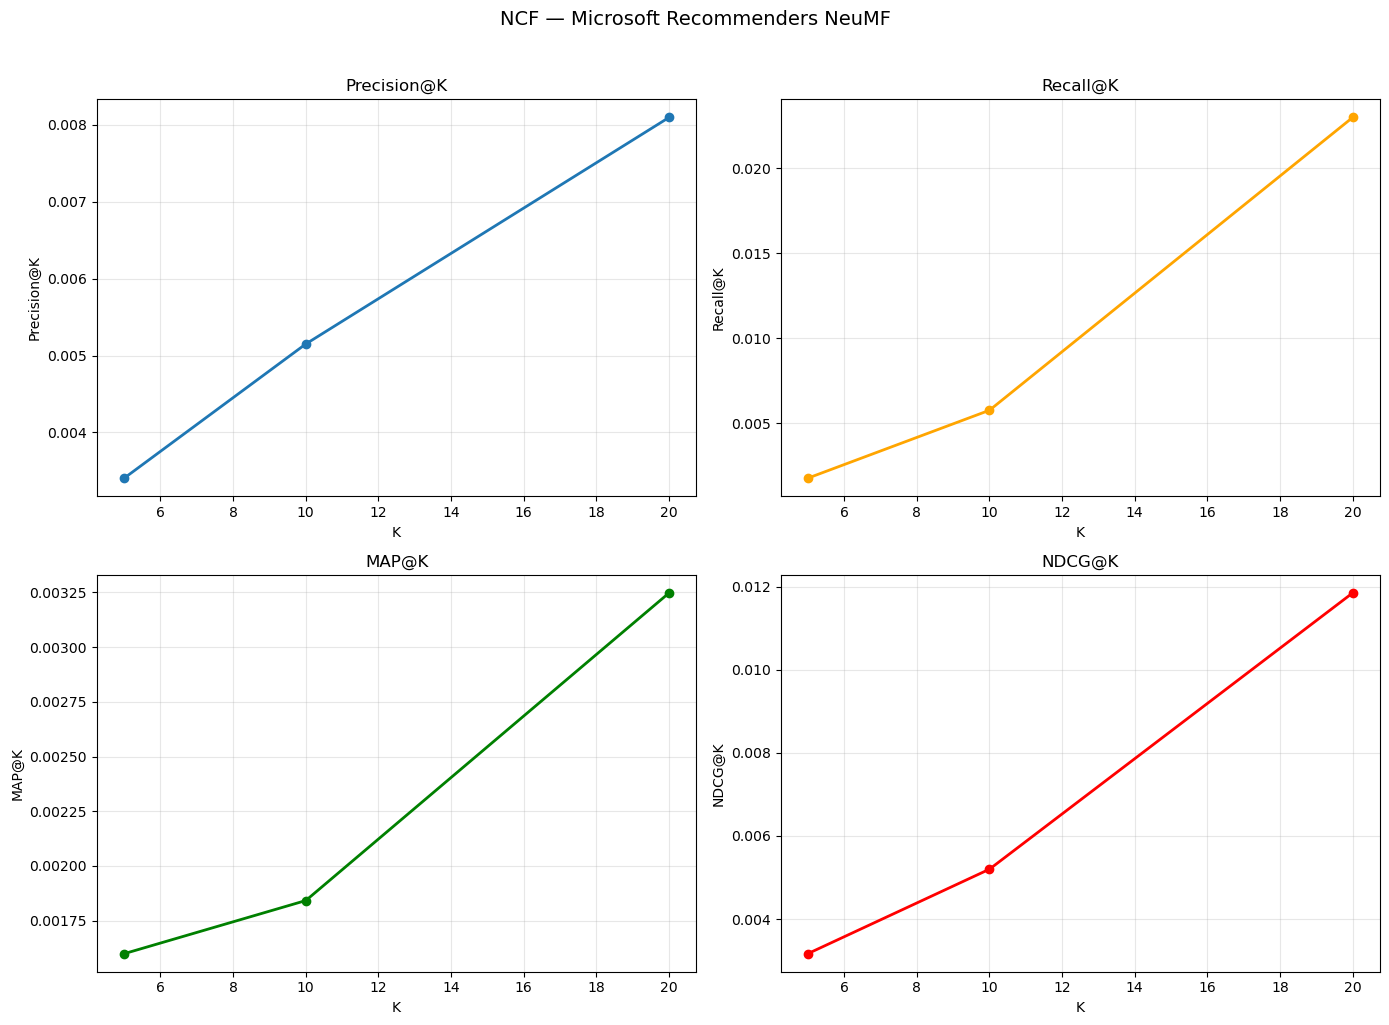

In [18]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'K'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df['precision'], marker='o', linewidth=2)
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Precision@K')
axes[0, 0].set_title('Precision@K'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df['recall'], marker='o', linewidth=2, color='orange')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Recall@K')
axes[0, 1].set_title('Recall@K'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df['map'], marker='o', linewidth=2, color='green')
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('MAP@K')
axes[1, 0].set_title('MAP@K'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df['ndcg'], marker='o', linewidth=2, color='red')
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('NDCG@K')
axes[1, 1].set_title('NDCG@K'); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('NCF — Microsoft Recommenders NeuMF', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
EVAL_USERS = 500
SEARCH_EPOCHS = 10
EVAL_K = 10

rng = np.random.default_rng(42)
eval_users = rng.choice(test_users_eval, size=min(EVAL_USERS, len(test_users_eval)), replace=False).tolist()
eval_users_set = set(eval_users)
test_enc_small = test_enc_eval[test_enc_eval[DEFAULT_USER_COL].isin(eval_users_set)]

def quick_eval(model, users, known_items, test_df, k=EVAL_K):
    """Оценивает модель на подвыборке пользователей."""
    preds = []
    for u in users:
        scores = model.predict([u] * len(known_items), known_items, is_list=True)
        for item, score in zip(known_items, scores):
            preds.append({DEFAULT_USER_COL: u, DEFAULT_ITEM_COL: item, DEFAULT_RATING_COL: score})
    pred_df = pd.DataFrame(preds)
    return ndcg_at_k(test_df, pred_df, k=k,
                     col_user=DEFAULT_USER_COL, col_item=DEFAULT_ITEM_COL,
                     col_rating=DEFAULT_RATING_COL, col_prediction=DEFAULT_RATING_COL)

print(f"Пользователей в быстрой оценке: {len(eval_users)}")
print(f"Эпох при поиске: {SEARCH_EPOCHS}")

Пользователей в быстрой оценке: 500
Эпох при поиске: 10


In [20]:
param_grid_1 = {
    'learning_rate': [1e-4, 5e-4, 1e-3, 5e-3],
    'n_factors':     [16, 32, 64],
}

results_stage1 = []
total = len(param_grid_1['learning_rate']) * len(param_grid_1['n_factors'])
done = 0

for lr, nf in itertools.product(param_grid_1['learning_rate'], param_grid_1['n_factors']):
    t0 = time.time()
    m = NCF(
        n_users=data.n_users, n_items=data.n_items,
        model_type='NeuMF',
        n_factors=nf,
        layer_sizes=[256, 128, 64],   # фиксировано
        n_epochs=SEARCH_EPOCHS,
        batch_size=1024,
        learning_rate=lr,
        verbose=0,
        seed=42,
    )
    m.fit(data)
    score = quick_eval(m, eval_users, known_items, test_enc_small)
    elapsed = time.time() - t0
    done += 1
    results_stage1.append({'lr': lr, 'n_factors': nf, 'ndcg@10': score})
    print(f"[{done}/{total}] lr={lr:.0e}  n_factors={nf:2d}  NDCG@10={score:.4f}  ({elapsed:.0f}s)")

df_s1 = pd.DataFrame(results_stage1)
pivot1 = df_s1.pivot(index='lr', columns='n_factors', values='ndcg@10')
print("\nNDCG@10 (строки=lr, столбцы=n_factors):")
print(pivot1.to_string(float_format='{:.4f}'.format))

NameError: name 'itertools' is not defined

In [ ]:
best1 = df_s1.loc[df_s1['ndcg@10'].idxmax()]
BEST_LR = best1['lr']
BEST_NF = int(best1['n_factors'])
print(f"Лучшие из этапа 1: lr={BEST_LR:.0e}, n_factors={BEST_NF}  NDCG@10={best1['ndcg@10']:.4f}")

param_grid_2 = {
    'layer_sizes': [[64, 32], [128, 64], [256, 128, 64], [256, 128, 64, 32]],
    'n_neg':       [2, 4, 8],
}

results_stage2 = []
total2 = len(param_grid_2['layer_sizes']) * len(param_grid_2['n_neg'])
done = 0

for layers, n_neg in itertools.product(param_grid_2['layer_sizes'], param_grid_2['n_neg']):
    data_tmp = NCFDataset(
        train_file=train_file, test_file=test_file,
        seed=42, n_neg=n_neg, n_neg_test=99,
        col_user=DEFAULT_USER_COL, col_item=DEFAULT_ITEM_COL, col_rating=DEFAULT_RATING_COL,
    )
    t0 = time.time()
    m = NCF(
        n_users=data_tmp.n_users, n_items=data_tmp.n_items,
        model_type='NeuMF',
        n_factors=BEST_NF,
        layer_sizes=layers,
        n_epochs=SEARCH_EPOCHS,
        batch_size=1024,
        learning_rate=BEST_LR,
        verbose=0,
        seed=42,
    )
    m.fit(data_tmp)
    score = quick_eval(m, eval_users, known_items, test_enc_small)
    elapsed = time.time() - t0
    done += 1
    results_stage2.append({'layers': str(layers), 'n_neg': n_neg, 'ndcg@10': score})
    print(f"[{done}/{total2}] layers={layers}  n_neg={n_neg}  NDCG@10={score:.4f}  ({elapsed:.0f}s)")

df_s2 = pd.DataFrame(results_stage2)
pivot2 = df_s2.pivot(index='layers', columns='n_neg', values='ndcg@10')
print("\nNDCG@10 (строки=layers, столбцы=n_neg):")
print(pivot2.to_string(float_format='{:.4f}'.format))

In [ ]:
import ast

best2 = df_s2.loc[df_s2['ndcg@10'].idxmax()]
BEST_LAYERS = ast.literal_eval(best2['layers'])
BEST_N_NEG  = int(best2['n_neg'])
print(f"Лучшая конфигурация:")
print(f"  learning_rate = {BEST_LR:.0e}")
print(f"  n_factors     = {BEST_NF}")
print(f"  layer_sizes   = {BEST_LAYERS}")
print(f"  n_neg         = {BEST_N_NEG}")
print(f"  NDCG@10 (500 users) = {best2['ndcg@10']:.4f}")

# Финальное обучение с полным числом эпох
data_best = NCFDataset(
    train_file=train_file, test_file=test_file,
    seed=42, n_neg=BEST_N_NEG, n_neg_test=99,
    col_user=DEFAULT_USER_COL, col_item=DEFAULT_ITEM_COL, col_rating=DEFAULT_RATING_COL,
)

model_best = NCF(
    n_users=data_best.n_users, n_items=data_best.n_items,
    model_type='NeuMF',
    n_factors=BEST_NF,
    layer_sizes=BEST_LAYERS,
    n_epochs=20,
    batch_size=1024,
    learning_rate=BEST_LR,
    verbose=2,
    seed=42,
)
model_best.fit(data_best)

In [ ]:
known_items_best = sorted(model_best.item2id.keys())
test_users_best  = [u for u in test_enc[DEFAULT_USER_COL].unique() if u in set(model_best.user2id.keys())]

all_preds_best = []
for user in test_users_best:
    scores = model_best.predict([user] * len(known_items_best), known_items_best, is_list=True)
    for item, score in zip(known_items_best, scores):
        all_preds_best.append({DEFAULT_USER_COL: user, DEFAULT_ITEM_COL: item, DEFAULT_RATING_COL: score})

predictions_best = pd.DataFrame(all_preds_best)

test_enc_best = test_enc[
    test_enc[DEFAULT_USER_COL].isin(set(model_best.user2id.keys())) &
    test_enc[DEFAULT_ITEM_COL].isin(set(known_items_best))
]

print("=== Сравнение: базовая vs лучшая конфигурация ===\n")
print(f"{'K':>4}  {'Метрика':>12}  {'Базовая':>9}  {'Лучшая':>9}  {'Δ':>8}")
print("-" * 52)
for k in [5, 10, 20]:
    for metric_name, fn in [('Precision', precision_at_k), ('Recall', recall_at_k),
                             ('MAP', map_at_k), ('NDCG', ndcg_at_k)]:
        base = fn(test_enc_eval, predictions_df, k=k,
                  col_user=DEFAULT_USER_COL, col_item=DEFAULT_ITEM_COL,
                  col_rating=DEFAULT_RATING_COL, col_prediction=DEFAULT_RATING_COL)
        best = fn(test_enc_best, predictions_best, k=k,
                  col_user=DEFAULT_USER_COL, col_item=DEFAULT_ITEM_COL,
                  col_rating=DEFAULT_RATING_COL, col_prediction=DEFAULT_RATING_COL)
        delta = best - base
        sign = '+' if delta >= 0 else ''
        print(f"{k:>4}  {metric_name+'@'+str(k):>12}  {base:>9.4f}  {best:>9.4f}  {sign}{delta:>7.4f}")